In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving A-3_지하철 승하차 인원 기반 KPI 대시보드 구축.csv to A-3_지하철 승하차 인원 기반 KPI 대시보드 구축 (3).csv


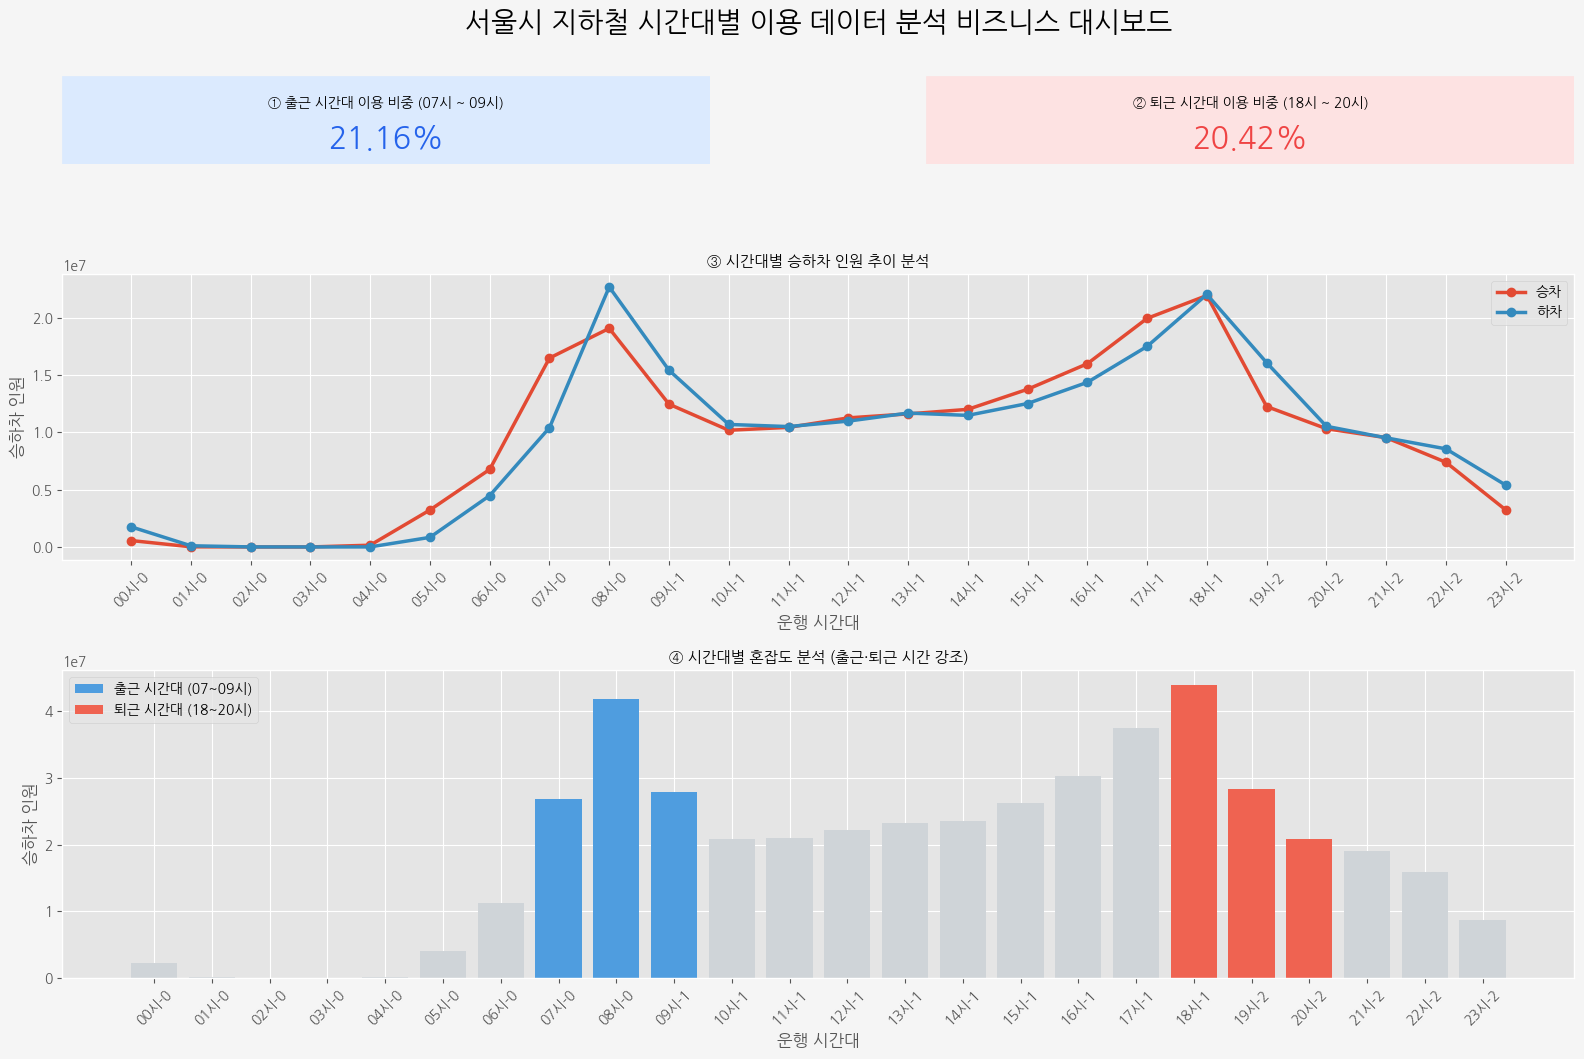



KPI 요약
전체 승하차 인원 : 456,428,823명
출근시간 비중    : 21.16%
퇴근시간 비중    : 20.42%


In [12]:
# ============================================================
# 서울시 지하철 시간대별 이용 데이터 분석 비즈니스 대시보드
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files
from matplotlib.patches import Rectangle, Patch

# ============================================================
# 한글 폰트
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 파일 업로드
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name, encoding='cp949')

# ============================================================
# 시간대 컬럼 추출
# ============================================================

ride_cols = [c for c in df.columns if "승차인원" in c]
drop_cols = [c for c in df.columns if "하차인원" in c]

# ============================================================
# 시간 순서 정렬
# ============================================================

ride_cols = sorted(
    ride_cols,
    key=lambda x: int(x[:2])
)

drop_cols = sorted(
    drop_cols,
    key=lambda x: int(x[:2])
)

# ============================================================
# 전체 역 합산
# ============================================================

ride_total = df[ride_cols].sum()

drop_total = df[drop_cols].sum()

# ============================================================
# 시간대 데이터 생성
# ============================================================

time_labels = [c[:5] for c in ride_cols]

hours = [int(c[:2]) for c in ride_cols]

hour_df = pd.DataFrame({
    "시간대": time_labels,
    "hour": hours,
    "승차": ride_total.values,
    "하차": drop_total.values
})

hour_df["합계"] = (
    hour_df["승차"]
    + hour_df["하차"]
)

# ============================================================
# KPI 계산
# ============================================================

total_users = hour_df["합계"].sum()

morning_hours = [7,8,9]

evening_hours = [18,19,20]

morning_total = hour_df[
    hour_df["hour"].isin(morning_hours)
]["합계"].sum()

evening_total = hour_df[
    hour_df["hour"].isin(evening_hours)
]["합계"].sum()

morning_ratio = (
    morning_total
    / total_users
    * 100
)

evening_ratio = (
    evening_total
    / total_users
    * 100
)

# ============================================================
# 그래프 스타일
# ============================================================

plt.style.use("ggplot")

fig = plt.figure(
    figsize=(18,11),
    facecolor="#f5f5f5"
)

fig.suptitle(
    "서울시 지하철 시간대별 이용 데이터 분석 비즈니스 대시보드",
    fontsize=20,
    fontweight="bold"
)

# ============================================================
# KPI 카드
# ============================================================

ax_card1 = plt.axes([0.08,0.84,0.36,0.08])
ax_card2 = plt.axes([0.56,0.84,0.36,0.08])

for ax in [ax_card1, ax_card2]:
    ax.axis("off")

# 출근

ax_card1.add_patch(
    Rectangle(
        (0,0),
        1,
        1,
        color="#dbeafe"
    )
)

ax_card1.text(
    0.5,
    0.65,
    "① 출근 시간대 이용 비중 (07시 ~ 09시)",
    ha="center",
    fontsize=10
)

ax_card1.text(
    0.5,
    0.18,
    f"{morning_ratio:.2f}%",
    ha="center",
    fontsize=22,
    color="#2563eb"
)

# 퇴근

ax_card2.add_patch(
    Rectangle(
        (0,0),
        1,
        1,
        color="#fde2e2"
    )
)

ax_card2.text(
    0.5,
    0.65,
    "② 퇴근 시간대 이용 비중 (18시 ~ 20시)",
    ha="center",
    fontsize=10
)

ax_card2.text(
    0.5,
    0.18,
    f"{evening_ratio:.2f}%",
    ha="center",
    fontsize=22,
    color="#ef4444"
)

# ============================================================
# 승차/하차 추이
# ============================================================

ax1 = plt.axes([0.08,0.48,0.84,0.26])

ax1.plot(
    hour_df["시간대"],
    hour_df["승차"],
    marker="o",
    linewidth=2.5,
    label="승차"
)

ax1.plot(
    hour_df["시간대"],
    hour_df["하차"],
    marker="o",
    linewidth=2.5,
    label="하차"
)

ax1.set_title(
    "③ 시간대별 승하차 인원 추이 분석",
    fontsize=11,
    fontweight="bold"
)

ax1.set_xlabel("운행 시간대")
ax1.set_ylabel("승하차 인원")

ax1.legend()

ax1.tick_params(
    axis="x",
    rotation=45
)

# ============================================================
# 혼잡도 분석
# ============================================================

ax2 = plt.axes([0.08,0.10,0.84,0.28])

colors = []

for h in hour_df["hour"]:

    if h in morning_hours:
        colors.append("#4f9ddf")

    elif h in evening_hours:
        colors.append("#ef6351")

    else:
        colors.append("#cfd4d8")

bars = ax2.bar(
    hour_df["시간대"],
    hour_df["합계"],
    color=colors
)

ax2.set_title(
    "④ 시간대별 혼잡도 분석 (출근·퇴근 시간 강조)",
    fontsize=11,
    fontweight="bold"
)

ax2.set_xlabel("운행 시간대")
ax2.set_ylabel("승하차 인원")

ax2.tick_params(
    axis="x",
    rotation=45
)

legend_elements = [
    Patch(
        facecolor="#4f9ddf",
        label="출근 시간대 (07~09시)"
    ),
    Patch(
        facecolor="#ef6351",
        label="퇴근 시간대 (18~20시)"
    )
]

ax2.legend(
    handles=legend_elements,
    loc="upper left"
)

plt.show()

# ============================================================
# KPI 출력
# ============================================================

print("\n")
print("="*60)
print("KPI 요약")
print("="*60)

print(f"전체 승하차 인원 : {total_users:,.0f}명")
print(f"출근시간 비중    : {morning_ratio:.2f}%")
print(f"퇴근시간 비중    : {evening_ratio:.2f}%")